# ДЗ №2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv("immunology_dataset.csv")
df.head()

,Group,Gender,Age,BMI,IL6_expression,TNF_expression,CRP,WBC,Autoantibodies
0,Cancer,M,52,24.3,14.55,2.30,4.7,10.4,1
1,Autoimmune,F,21,22.6,10.75,18.85,20.1,8.1,1
2,Healthy,F,42,24.8,2.24,3.12,0.2,6.6,0
3,Cancer,M,60,21.8,8.15,7.04,4.3,13.4,0
4,Cancer,F,49,28.4,13.86,3.78,0.1,5.5,0


## 1) Проверка количественных переменных на нормальность

In [2]:
quant_vars = ['Age', 'BMI', 'IL6_expression', 'TNF_expression', 'CRP', 'WBC']

normality = {'Age': {'W': 0.9884007667050628, 'p': 0.5382105731948345}, 'BMI': {'W': 0.9946530333810354, 'p': 0.9651500142921079}, 'IL6_expression': {'W': 0.9141212774556133, 'p': 6.955900314526998e-06}, 'TNF_expression': {'W': 0.9165993712690429, 'p': 9.332324098124695e-06}, 'CRP': {'W': 0.6452492988443829, 'p': 3.392531721929531e-14}, 'WBC': {'W': 0.9816540024672402, 'p': 0.1784897132054304}}

pd.DataFrame([
    {"variable": v, "Shapiro_W": normality[v]["W"], "p_value": normality[v]["p"]}
    for v in quant_vars
]).sort_values("p_value")

,variable,Shapiro_W,p_value
4,CRP,0.645249,3.392532e-14
2,IL6_expression,0.914121,6.955900e-06
3,TNF_expression,0.916599,9.332324e-06
5,WBC,0.981654,1.784897e-01
0,Age,0.988401,5.382106e-01
1,BMI,0.994653,9.651500e-01


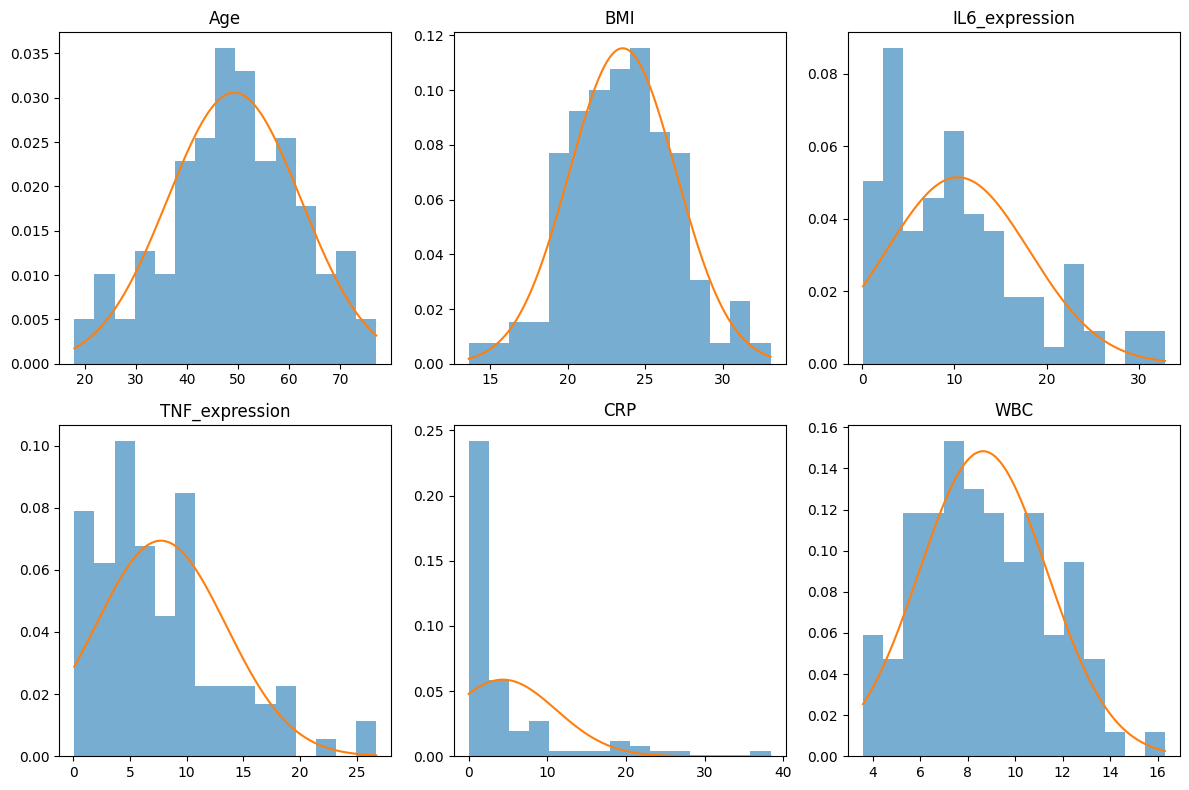

In [3]:
fig = plt.figure(figsize=(12,8))
for i,v in enumerate(quant_vars,1):
    ax = fig.add_subplot(2,3,i)
    x = df[v].values
    ax.hist(x, bins=15, density=True, alpha=0.6)
    mu, sigma = np.mean(x), np.std(x, ddof=1)
    xs = np.linspace(x.min(), x.max(), 200)
    ax.plot(xs, stats.norm.pdf(xs, mu, sigma))
    ax.set_title(v)
plt.tight_layout()
plt.show()

## 2) Диаграммы рассеяния

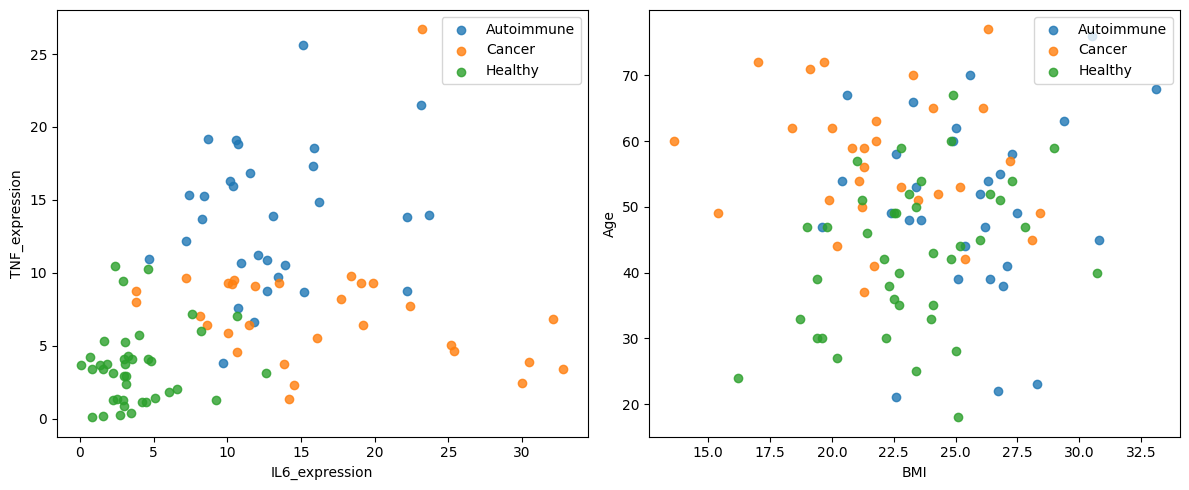

In [4]:
fig = plt.figure(figsize=(12,5))

ax1 = fig.add_subplot(1,2,1)
for g,sub in df.groupby("Group"):
    ax1.scatter(sub["IL6_expression"], sub["TNF_expression"], label=g, alpha=0.8)
ax1.set_xlabel("IL6_expression")
ax1.set_ylabel("TNF_expression")
ax1.legend()

ax2 = fig.add_subplot(1,2,2)
for g,sub in df.groupby("Group"):
    ax2.scatter(sub["BMI"], sub["Age"], label=g, alpha=0.8)
ax2.set_xlabel("BMI")
ax2.set_ylabel("Age")
ax2.legend()

plt.tight_layout()
plt.show()

Между IL6 и TNF может существовать положительная корреляция.
Между BMI и Age выраженной взаимосвязи не наблюдается (корреляция либо отсутствует, либо очень слабая).

## 3) Тепловая карта корреляций (Spearman) и пары с +/− корреляцией

In [5]:
quant_vars = ["Age","BMI","IL6_expression","TNF_expression","CRP","WBC"]
corr = df[quant_vars].corr(method="spearman")
corr

,Age,BMI,IL6_expression,TNF_expression,CRP,WBC
Age,1.000000,0.023203,0.359773,0.141490,0.347784,0.286712
BMI,0.023203,1.000000,-0.003361,0.228441,0.170919,0.107584
IL6_expression,0.359773,-0.003361,1.000000,0.469977,0.547502,0.393812
TNF_expression,0.141490,0.228441,0.469977,1.000000,0.575856,0.391649
CRP,0.347784,0.170919,0.547502,0.575856,1.000000,0.370040
WBC,0.286712,0.107584,0.393812,0.391649,0.370040,1.000000


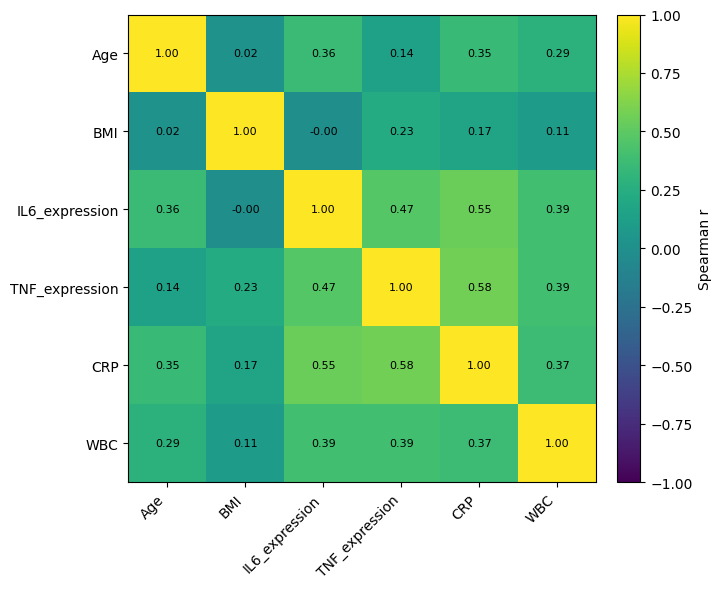

In [6]:
fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(1,1,1)
cax = ax.imshow(corr.values, vmin=-1, vmax=1)
ax.set_xticks(range(len(quant_vars)))
ax.set_xticklabels(quant_vars, rotation=45, ha="right")
ax.set_yticks(range(len(quant_vars)))
ax.set_yticklabels(quant_vars)
fig.colorbar(cax, ax=ax, fraction=0.046, pad=0.04, label="Spearman r")
for i in range(len(quant_vars)):
    for j in range(len(quant_vars)):
        ax.text(j,i,f"{corr.values[i,j]:.2f}",ha="center",va="center",fontsize=8)
plt.tight_layout()
plt.show()

In [7]:
pairs = []
for i in range(len(quant_vars)):
    for j in range(i+1, len(quant_vars)):
        a,b = quant_vars[i], quant_vars[j]
        r = corr.loc[a,b]
        pairs.append((a,b,r))
pairs_sorted = sorted(pairs, key=lambda x: x[2])
neg = [p for p in pairs_sorted if p[2] < 0]
pos = [p for p in pairs_sorted if p[2] > 0]

pd.DataFrame(pos, columns=["var1","var2","spearman_r"]).sort_values("spearman_r", ascending=False), pd.DataFrame(neg, columns=["var1","var2","spearman_r"])

(              var1            var2  spearman_r
 13  TNF_expression             CRP    0.575856
 12  IL6_expression             CRP    0.547502
 11  IL6_expression  TNF_expression    0.469977
 10  IL6_expression             WBC    0.393812
 9   TNF_expression             WBC    0.391649
 8              CRP             WBC    0.370040
 7              Age  IL6_expression    0.359773
 6              Age             CRP    0.347784
 5              Age             WBC    0.286712
 4              BMI  TNF_expression    0.228441
 3              BMI             CRP    0.170919
 2              Age  TNF_expression    0.141490
 1              BMI             WBC    0.107584
 0              Age             BMI    0.023203,
   var1            var2  spearman_r
 0  BMI  IL6_expression   -0.003361)

## 4) Корреляция IL6 и TNFα

In [8]:
def spearman_report(x, y):
    r, p = stats.spearmanr(x, y)
    return r, p

overall_r, overall_p = spearman_report(df["IL6_expression"], df["TNF_expression"])

by_group = {}
for g, sub in df.groupby("Group"):
    by_group[g] = spearman_report(sub["IL6_expression"], sub["TNF_expression"])

overall_r, overall_p, by_group

(np.float64(0.4699772275368377),
 np.float64(8.083782720097081e-07),
 {'Autoimmune': (np.float64(0.03670745272525028),
   np.float64(0.8472906542071432)),
  'Cancer': (np.float64(-0.3059294712445078), np.float64(0.1001482003259218)),
  'Healthy': (np.float64(0.13725490256482328),
   np.float64(0.3983581586845464))})

В общей выборке видно положительную корреляцию между IL6 и TNFα (ρ ≈ 0.47, p < 0.05).
При анализе по отдельным группам значимой корреляции не выявлено. Связь присутствует в объединённой выборке, но внутри групп она не подтверждается.

## 5) Отличается ли IL6 между Healthy и Cancer?

In [9]:
healthy = df[df.Group=="Healthy"]["IL6_expression"]
cancer = df[df.Group=="Cancer"]["IL6_expression"]

mw = stats.mannwhitneyu(healthy, cancer, alternative="two-sided")
pd.DataFrame({
    "group": ["Healthy","Cancer"],
    "n": [len(healthy), len(cancer)],
    "mean": [healthy.mean(), cancer.mean()],
    "median": [healthy.median(), cancer.median()]
}), mw

(     group   n     mean  median
 0  Healthy  40   3.8265   3.060
 1   Cancer  30  16.4860  14.385,
 MannwhitneyuResult(statistic=np.float64(52.0), pvalue=np.float64(8.159540554362873e-11)))

У пациентов с онкологическим заболеванием уровень IL6 значимо выше, чем у здоровых (p < 0.05).

## 6) Отличается ли возраст между тремя группами?

In [10]:
groups = ["Healthy","Autoimmune","Cancer"]
age_groups = [df[df.Group==g]["Age"] for g in groups]

anova = stats.f_oneway(*age_groups)
means = df.groupby("Group")["Age"].agg(["count","mean","std"])
means, anova

(            count       mean        std
 Group                                  
 Autoimmune     30  50.533333  13.718182
 Cancer         30  56.700000  10.106843
 Healthy        40  42.700000  11.345845,
 F_onewayResult(statistic=np.float64(12.379555685073347), pvalue=np.float64(1.6278254140195364e-05)))

In [11]:
from itertools import combinations
pairs = []
for a,b in combinations(groups,2):
    x = df[df.Group==a]["Age"]
    y = df[df.Group==b]["Age"]
    res = stats.ttest_ind(x,y,equal_var=True)
    pairs.append((a,b,res.pvalue))
pair_df = pd.DataFrame(pairs, columns=["group1","group2","p_value"])
pair_df["p_bonferroni"] = np.minimum(pair_df["p_value"]*3, 1.0)
pair_df.sort_values("p_value")

,group1,group2,p_value,p_bonferroni
1,Healthy,Cancer,0.000001,0.000003
0,Healthy,Autoimmune,0.011045,0.033134
2,Autoimmune,Cancer,0.052195,0.156585


Возраст статистически значимо различается между группами (p < 0.05).

## 7) CRP выше в Autoimmune по сравнению со Healthy?

In [12]:
auto = df[df.Group=="Autoimmune"]["CRP"]
healthy = df[df.Group=="Healthy"]["CRP"]

mw_greater = stats.mannwhitneyu(auto, healthy, alternative="greater")
pd.DataFrame({
    "group": ["Autoimmune","Healthy"],
    "n": [len(auto), len(healthy)],
    "mean": [auto.mean(), healthy.mean()],
    "median": [auto.median(), healthy.median()]
}), mw_greater

(        group   n      mean  median
 0  Autoimmune  30  8.666667     4.5
 1     Healthy  40  0.675000     0.5,
 MannwhitneyuResult(statistic=np.float64(1069.0), pvalue=np.float64(1.3115611464127397e-08)))

Уровень CRP в группе аутоиммунных заболеваний выше, чем в группе здоровых (p < 0.05).

## 8) Связь между Group и наличием Autoantibodies

In [13]:
ct = pd.crosstab(df["Group"], df["Autoantibodies"])
chi2, p, dof, exp = stats.chi2_contingency(ct)
ct, (chi2, p, dof)

(Autoantibodies   0   1
 Group                 
 Autoimmune       7  23
 Cancer          23   7
 Healthy         33   7,
 (np.float64(29.17917917917918), np.float64(4.6112827005185607e-07), 2))

Между группой (Healthy / Autoimmune / Cancer) и наличием аутоантител существует связь (p < 0.05).

## 9) Связь между Gender и Autoantibodies в группе Autoimmune

In [14]:
sub = df[df.Group=="Autoimmune"]
ct2 = pd.crosstab(sub["Gender"], sub["Autoantibodies"])
odds, p = stats.fisher_exact(ct2)
ct2, (odds, p)

(Autoantibodies  0   1
 Gender               
 F               7  15
 M               0   8,
 (inf, np.float64(0.1433854013164358)))

Нет, статистически значимой связи не заметила (p > 0.05).

## 10) Какие переменные отличаются между Autoimmune и Cancer?

In [15]:
auto = df[df.Group=="Autoimmune"]
can = df[df.Group=="Cancer"]

quant_vars = ["Age","BMI","IL6_expression","TNF_expression","CRP","WBC"]

rows = []
for v in quant_vars:
    x = auto[v]
    y = can[v]
    p1 = stats.shapiro(x).pvalue
    p2 = stats.shapiro(y).pvalue
    lev = stats.levene(x, y).pvalue
    if p1>0.05 and p2>0.05 and lev>0.05:
        res = stats.ttest_ind(x, y, equal_var=True)
        test = "t-test"
        stat = res.statistic
        p = res.pvalue
    else:
        res = stats.mannwhitneyu(x, y, alternative="two-sided")
        test = "mannwhitney"
        stat = res.statistic
        p = res.pvalue
    rows.append([v, test, stat, p, x.mean(), y.mean(), x.median(), y.median()])

out = pd.DataFrame(rows, columns=["variable","test","statistic","p_value","mean_auto","mean_cancer","median_auto","median_cancer"])

# Benjamini–Hochberg FDR
pvals = out["p_value"].values
order = np.argsort(pvals)
ranked = pvals[order]
adj = np.empty_like(ranked)
prev = 1.0
n = len(pvals)
for i in range(n-1, -1, -1):
    rank = i+1
    val = ranked[i] * n / rank
    prev = min(prev, val)
    adj[i] = prev
adj_full = np.empty(n)
adj_full[order] = adj
out["p_fdr_bh"] = adj_full
out.sort_values("p_value")

,variable,test,statistic,p_value,mean_auto,mean_cancer,median_auto,median_cancer,p_fdr_bh
3,TNF_expression,mannwhitney,787.000000,6.523812e-07,13.684000,7.338333,13.86,6.955,0.000004
1,BMI,t-test,4.142663,1.129278e-04,25.563333,22.010000,25.80,21.500,0.000339
0,Age,t-test,-1.982258,5.219488e-02,50.533333,56.700000,50.50,56.500,0.104390
2,IL6_expression,mannwhitney,348.000000,1.334541e-01,12.963000,16.486000,11.96,14.385,0.184257
4,CRP,mannwhitney,547.000000,1.535472e-01,8.666667,4.906667,4.50,3.150,0.184257
5,WBC,mannwhitney,442.000000,9.116821e-01,9.813333,9.666667,9.80,10.450,0.911682


Статистически значимо различаются BMI и TNF_expression.
Остальные переменные (Age, IL6_expression, CRP, WBC) значимых различий не показали (p > 0.05 после коррекции).